# 08 -- Blending

Смешиваю три готовых submission:

- [lstm_fixed_hyperparameters.csv](/submissions/lstm_fixed_hyperparameters.csv);
- [one_staged_catboost.csv](/submissions/one_staged_catboost.csv);
- [Two_Staged_Submission.csv](/submissions/Two_Staged_Submission.csv).

Имея только готовые prediction без validation/OOF target, корректно обучить stacker или подобрать оптимальные веса нельзя. Поэтому здесь делаю два простых blend:

1. uniform;
2. веса обратно пропорциональны public RMSLE.

Смешиваю **в `log1p`-пространстве**, потому что leaderboard-метрика -- RMSLE.

## Почему log-space

RMSLE считает ошибку между

$$
\log(1 + y)
$$

и

$$
\log(1 + \hat y).
$$

Поэтому смешиваю модели так:

$$
z_i = \log(1 + \hat y_i),
$$

$$
z_{blend} = \sum_i w_i z_i,
$$

$$
\hat y_{blend} = \exp(z_{blend}) - 1.
$$

Это лучше согласовано с метрикой, чем обычное среднее предсказаний в рублях.

In [8]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / "submissions").exists() and (path / "data" / "sample_submit.csv").exists():
            return path
    raise FileNotFoundError("Не найден корень проекта")


PROJECT_ROOT = find_project_root()
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions"

FILES = {
    "lstm": "lstm_fixed_hyperparameters.csv",
    "catboost": "one_staged_catboost.csv",
    "two_stage": "Two_Staged_Submission.csv",
}

PUBLIC_RMSLE = {
    "lstm": 1.6529693117,
    "catboost": 1.6609167284,
    "two_stage": 1.6550467208,
}

ID_COL = "user_id"
PRED_COL = "predict"

print("project:", PROJECT_ROOT)

project: /Users/pinta/Dev/E-CUP-2026


## Загружаю submissions

In [4]:
sample = pd.read_csv(PROJECT_ROOT / "data" / "sample_submit.csv")

predictions = {}

for name, filename in FILES.items():
    df = pd.read_csv(SUBMISSIONS_DIR / filename)
    predictions[name] = (
        df.set_index(ID_COL)[PRED_COL]
        .reindex(sample[ID_COL])
        .to_numpy(dtype=np.float64)
    )

    if np.isnan(predictions[name]).any():
        raise ValueError(f"В {filename} не совпадают user_id с sample_submit.csv")

    predictions[name] = np.clip(predictions[name], 0, None)

print({name: len(pred) for name, pred in predictions.items()})

{'lstm': 250000, 'catboost': 250000, 'two_stage': 250000}


## Корреляции сабмитов

Чем меньше корреляция между моделями, тем потенциально полезнее blend.

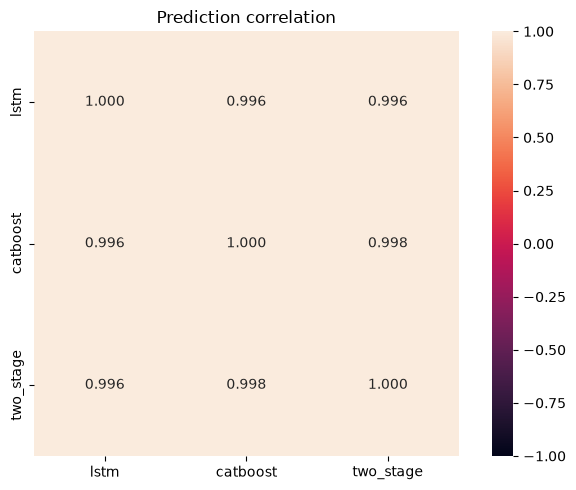

In [12]:
log_predictions = pd.DataFrame({
    name: np.log1p(pred)
    for name, pred in predictions.items()
})

prediction_correlation = log_predictions.corr()

fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    prediction_correlation,
    annot=True,
    fmt=".3f",
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
)

ax.set_title("Prediction correlation")
plt.tight_layout()
plt.show()

> бленд юзлесс пока, понятно.

## Uniform blend

Все три модели имеют одинаковый вес `1/3`.

In [6]:
names = list(predictions)

uniform_weights = {
    name: 1 / len(names)
    for name in names
}

uniform_log = sum(
    uniform_weights[name] * np.log1p(predictions[name])
    for name in names
)

uniform_pred = np.expm1(uniform_log)

uniform_submission = sample.copy()
uniform_submission[PRED_COL] = uniform_pred

uniform_path = SUBMISSIONS_DIR / "blend_uniform_log.csv"
uniform_submission.to_csv(uniform_path, index=False)

print("weights:", uniform_weights)
print("saved:", uniform_path)
uniform_submission.head()

weights: {'lstm': 0.3333333333333333, 'catboost': 0.3333333333333333, 'two_stage': 0.3333333333333333}
saved: /Users/pinta/Dev/E-CUP-2026/submissions/blend_uniform_log.csv


,user_id,predict
0,2,1.883175
1,7,84.154149
2,15,7.160378
3,18,145.036137
4,23,0.509623


## Blend по public RMSLE

У RMSLE меньше -- лучше, поэтому беру

$$
w_i \propto \frac{1}{RMSLE_i}.
$$

После этого нормирую веса так, чтобы их сумма была равна 1.

_Так как наши три public score очень близки, веса тоже будут близки к uniform._

In [7]:
inverse_scores = {
    name: 1 / PUBLIC_RMSLE[name]
    for name in names
}

weight_sum = sum(inverse_scores.values())

rmsle_weights = {
    name: inverse_scores[name] / weight_sum
    for name in names
}

weighted_log = sum(
    rmsle_weights[name] * np.log1p(predictions[name])
    for name in names
)

weighted_pred = np.expm1(weighted_log)

weighted_submission = sample.copy()
weighted_submission[PRED_COL] = weighted_pred

weighted_path = SUBMISSIONS_DIR / "blend_inverse_rmsle_log.csv"
weighted_submission.to_csv(weighted_path, index=False)

print("weights:")
for name, weight in rmsle_weights.items():
    print(f"{name:10s}: {weight:.4f}")

print("saved:", weighted_path)
weighted_submission.head()

weights:
lstm      : 0.3340
catboost  : 0.3324
two_stage : 0.3336
saved: /Users/pinta/Dev/E-CUP-2026/submissions/blend_inverse_rmsle_log.csv


,user_id,predict
0,2,1.883119
1,7,84.147016
2,15,7.159404
3,18,145.013502
4,23,0.509447


## Результат

После запуска в `submissions/` появятся:

- [blend_uniform_log.csv](/submissions/blend_uniform_log.csv);
- [blend_inverse_rmsle_log.csv](/submissions/blend_inverse_rmsle_log.csv).

> Веса блендов очень похожи, залью `uniform` только  
> upd: действительно бленд юзлесс -- 1.6537790895... хотя, у 2/3 моделей оттуда маргинальный скор был ниже, хммм